In [ ]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/ronakgohil/license-plate-dataset")

In [2]:
import os

train_img = len(os.listdir('/content/license-plate-dataset/archive/images/train'))
train_labels = len(os.listdir('/content/license-plate-dataset/archive/labels/train'))

val_img = len(os.listdir('/content/license-plate-dataset/archive/images/val'))
val_labels = len(os.listdir('/content/license-plate-dataset/archive/labels/val'))

print(train_img, train_labels, val_img, val_labels)

1526 1526 169 169


In [4]:
import os
import random
import shutil
from sklearn.model_selection import train_test_split

train_img = [f"/content/license-plate-dataset/archive/images/train/{i}" for i in os.listdir("/content/license-plate-dataset/archive/images/train")]
val_img = [f"/content/license-plate-dataset/archive/images/val/{i}" for i in os.listdir("/content/license-plate-dataset/archive/images/val")]

all_imgs = train_img + val_img

random.shuffle(all_imgs)

train_data, temp_data = train_test_split(all_imgs, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.33, random_state=42)

print(len(train_data), len(val_data), len(test_data))

os.makedirs("/content/license-plate-dataset/final/train/images", exist_ok=True)
os.makedirs("/content/license-plate-dataset/final/train/labels", exist_ok=True)

os.makedirs("/content/license-plate-dataset/final/val/images", exist_ok=True)
os.makedirs("/content/license-plate-dataset/final/val/labels", exist_ok=True)

os.makedirs("/content/license-plate-dataset/final/test/images", exist_ok=True)
os.makedirs("/content/license-plate-dataset/final/test/labels", exist_ok=True)

print("Folders created")

1186 341 168
Folders created


In [18]:
for img_path in train_data:
    img_name = os.path.basename(img_path)

    shutil.copy(
        img_path,
        f"/content/license-plate-dataset/final/train/images/{img_name}"
    )

for img_path in val_data:
    img_name = os.path.basename(img_path)

    shutil.copy(
        img_path,
        f"/content/license-plate-dataset/final/val/images/{img_name}"
    )

for img_path in test_data:
    img_name = os.path.basename(img_path)

    shutil.copy(
        img_path,
        f"/content/license-plate-dataset/final/test/images/{img_name}"
    )

In [20]:
print(len(os.listdir('/content/license-plate-dataset/final/train/images')))
print(len(os.listdir('/content/license-plate-dataset/final/val/images')))
print(len(os.listdir('/content/license-plate-dataset/final/test/images')))

1186
341
168


In [21]:
for img_path in train_data:

    label_name = os.path.basename(img_path).rsplit(".",1)[0] + ".txt"

    if "train" in img_path:
        label_path = f"/content/license-plate-dataset/archive/labels/train/{label_name}"
    else:
        label_path = f"/content/license-plate-dataset/archive/labels/val/{label_name}"

    shutil.copy(
        label_path,
        f"/content/license-plate-dataset/final/train/labels/{label_name}"
    )

In [22]:
for img_path in val_data:

    label_name = os.path.basename(img_path).rsplit(".",1)[0] + ".txt"

    if "train" in img_path:
        label_path = f"/content/license-plate-dataset/archive/labels/train/{label_name}"
    else:
        label_path = f"/content/license-plate-dataset/archive/labels/val/{label_name}"

    shutil.copy(
        label_path,
        f"/content/license-plate-dataset/final/val/labels/{label_name}"
    )

In [23]:
for img_path in test_data:

    label_name = os.path.basename(img_path).rsplit(".",1)[0] + ".txt"

    if "train" in img_path:
        label_path = f"/content/license-plate-dataset/archive/labels/train/{label_name}"
    else:
        label_path = f"/content/license-plate-dataset/archive/labels/val/{label_name}"

    shutil.copy(
        label_path,
        f"/content/license-plate-dataset/final/test/labels/{label_name}"
    )

In [24]:
print(len(os.listdir('/content/license-plate-dataset/final/train/labels')))
print(len(os.listdir('/content/license-plate-dataset/final/val/labels')))
print(len(os.listdir('/content/license-plate-dataset/final/test/labels')))

1186
341
168


In [26]:
data = """
train: '/content/license-plate-dataset/final/train/images'
val: '/content/license-plate-dataset/final/val/images'
test: '/content/license-plate-dataset/final/test/images'

nc: 1

names:
  0: license_plate

"""

with open('/content/license-plate-dataset/final/data.yaml', 'w') as f:
  f.write(data)

(np.float64(-0.5), np.float64(271.5), np.float64(362.5), np.float64(-0.5))

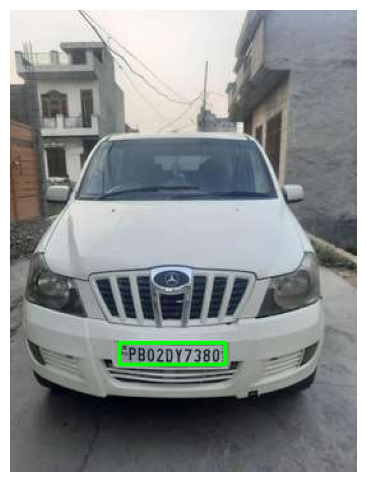

In [31]:
import os
import random
import cv2
import matplotlib.pyplot as plt

img_name = random.choice(os.listdir('/content/license-plate-dataset/final/train/images'))
img_path = f'/content/license-plate-dataset/final/train/images/{img_name}'

label_name = img_name.rsplit('.',1)[0] + '.txt'
label_path = f'/content/license-plate-dataset/final/train/labels/{label_name}'

img = cv2.imread(img_path)

h, w, _ = img.shape

# read label
with open(label_path, 'r') as f:
    label = f.readline().split()

# YOLO values
class_id, x_center, y_center, bw, bh = map(float, label)

# convert to pixels
x_center *= w
y_center *= h
bw *= w
bh *= h

# corners
x1 = int(x_center - bw/2)
y1 = int(y_center - bh/2)

x2 = int(x_center + bw/2)
y2 = int(y_center + bh/2)

# draw box
cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

# show
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

In [34]:
model = YOLO('yolov8n')

In [ ]:
model.train(data='/content/license-plate-dataset/final/data.yaml', epochs=30, batch=16, imgsz=640)

In [41]:
model1 = YOLO('/content/runs/detect/train-2/weights/best.pt')


image 1/1 /content/license-plate-dataset/final/test/images/07bd977e-d578-49a2-b345-7cee5a4db6bf___new_1031520d1356604430-skoda-rapid-joins-family-edit-sold-wp_000281.jpg.jpg: 480x640 1 license_plate, 10.9ms
Speed: 3.6ms preprocess, 10.9ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)


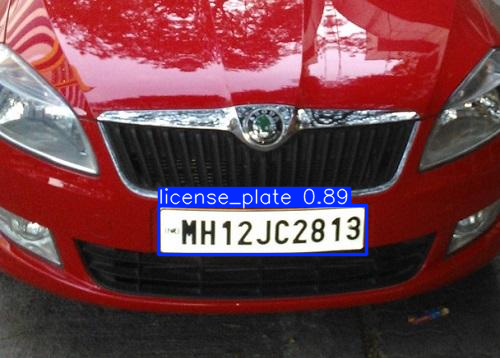

In [43]:
res = model1('/content/license-plate-dataset/final/test/images/07bd977e-d578-49a2-b345-7cee5a4db6bf___new_1031520d1356604430-skoda-rapid-joins-family-edit-sold-wp_000281.jpg.jpg')

res[0].show()

In [47]:
boxes = res[0].boxes.xyxy
print(boxes)

tensor([[158.1312, 205.2989, 366.2101, 254.5863]], device='cuda:0')


In [48]:
x1, y1, x2, y2 = map(int, boxes[0])

print(x1, y1, x2, y2)

158 205 366 254


In [51]:
import cv2

img = cv2.imread('/content/license-plate-dataset/final/test/images/07bd977e-d578-49a2-b345-7cee5a4db6bf___new_1031520d1356604430-skoda-rapid-joins-family-edit-sold-wp_000281.jpg.jpg')

In [54]:
plate = img[y1:y2, x1:x2]

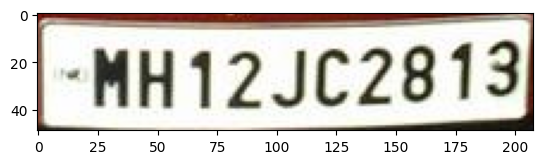

In [56]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(plate, cv2.COLOR_RGB2BGR))

In [ ]:
!pip install easyocr

In [59]:
from easyocr import Reader

reader = Reader(['en'])

text=''
result = reader.readtext(plate)

for r in result:
  text+= r[1]
  text+= ' '

print(text)

MH12JC2813 
